# Random Forest Classification: 3s / 25 Segments, augmented

This notebook trains and evaluates a Random Forest classifier using MFCC mean and standard deviation features extracted from 25 random 3-second segments per track.

A validation-based hyperparameter search is used to select suitable Random Forest parameters before final test evaluation.

In [ ]:
import sys
from pathlib import Path

current_path = Path.cwd()

for parent in [current_path] + list(current_path.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        break
else:
    raise FileNotFoundError("Could not find project root containing 'src' folder.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score
)
from sklearn.model_selection import ParameterGrid

from src.config import (
    MFCC_MEAN_TRAIN_PKL,
    MFCC_MEAN_VAL_PKL,
    MFCC_MEAN_TEST_PKL,
    MODEL_RESULTS_DIR,
    RANDOM_STATE
)

from src.model_functions import prepare_features_labels

In [ ]:
# ============================================================
# CONFIGURATION
# Central place to control all experiment parameters
# ============================================================

# --- Dataset ---
NORMALIZE_FEATURES = True
REDUCTION_FACTOR = 1         # Percentage of training data to keep
TARGET_COL = "genre"

# --- Training ---
MODEL_NAME = "RandomForest_3s_25_aug"

In [ ]:
# Read in pkl-Files which contain means of mfccs
df_features_tracks_train = pd.read_pickle(MFCC_MEAN_TRAIN_PKL)
df_features_tracks_val = pd.read_pickle(MFCC_MEAN_VAL_PKL)
df_features_tracks_test = pd.read_pickle(MFCC_MEAN_TEST_PKL)


In [ ]:
X_train, y_train, X_val, y_val, X_test, y_test = prepare_features_labels(
    df_features_tracks_train,
    df_features_tracks_val,
    df_features_tracks_test,
    target_col=TARGET_COL,
    normalize_features=NORMALIZE_FEATURES,
    reduction_factor=REDUCTION_FACTOR,
    random_state=RANDOM_STATE
)

In [9]:
# ---------------------------------------------------
# DEFINE RANDOM FOREST
# ---------------------------------------------------
# n_estimators: number of trees in the forest
# min_samples_split: minimum number of samples required to split a node
# max_features: number of features considered when looking for the best split
# max_depth: maximum depth of each tree (None = expand until leaves are pure)
# random_state: ensures reproducibility of the results
clf = RandomForestClassifier(
        n_estimators=500,
        max_depth= 30, 
        min_samples_split= 5,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )

# Train the model using the training dataset
clf.fit(X_train, y_train)

# Evaluate the model on the validation dataset
val_score = clf.score(X_val, y_val)
print("Validation Score:", val_score)

# Evaluate the model on the test dataset
test_score = clf.score(X_test, y_test)
print("Test Score:", test_score)

# Generate predictions for the test dataset
y_pred = clf.predict(X_test)

Validation Score: 0.6366037735849056
Test Score: 0.6177358490566037


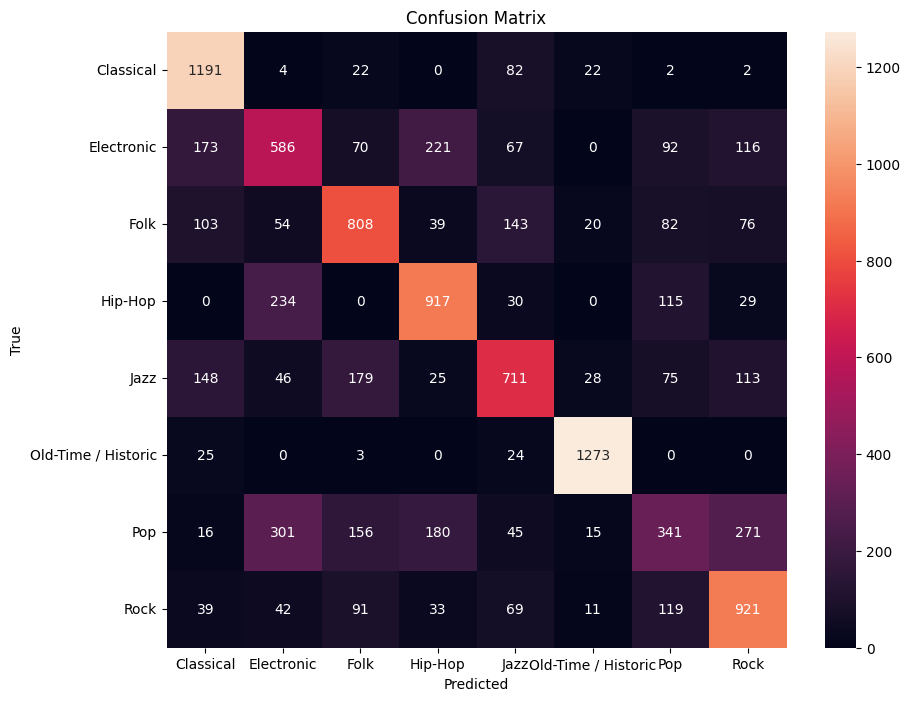

Classification Report Validation Set:
                      precision    recall  f1-score   support

          Classical       0.70      0.90      0.79      1325
         Electronic       0.46      0.44      0.45      1325
               Folk       0.61      0.61      0.61      1325
            Hip-Hop       0.65      0.69      0.67      1325
               Jazz       0.61      0.54      0.57      1325
Old-Time / Historic       0.93      0.96      0.95      1325
                Pop       0.41      0.26      0.32      1325
               Rock       0.60      0.70      0.65      1325

           accuracy                           0.64     10600
          macro avg       0.62      0.64      0.62     10600
       weighted avg       0.62      0.64      0.62     10600

Balanced Accuracy: 0.6366037735849057
F1-Macro: 0.624576270664509


In [10]:
# ---------------------------------------------------
# CONFUSION MATRIX VALIDATION SET
# ---------------------------------------------------
y_pred_val = clf.predict(X_val)

cm = confusion_matrix(y_val, y_pred_val,labels=clf.classes_)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report Validation Set:\n", classification_report(y_val, y_pred_val, target_names=clf.classes_))

# Balanced Accuracy
print("Balanced Accuracy:", balanced_accuracy_score(y_val, y_pred_val))

# F1-Macro
print("F1-Macro:", f1_score(y_val, y_pred_val, average='macro'))


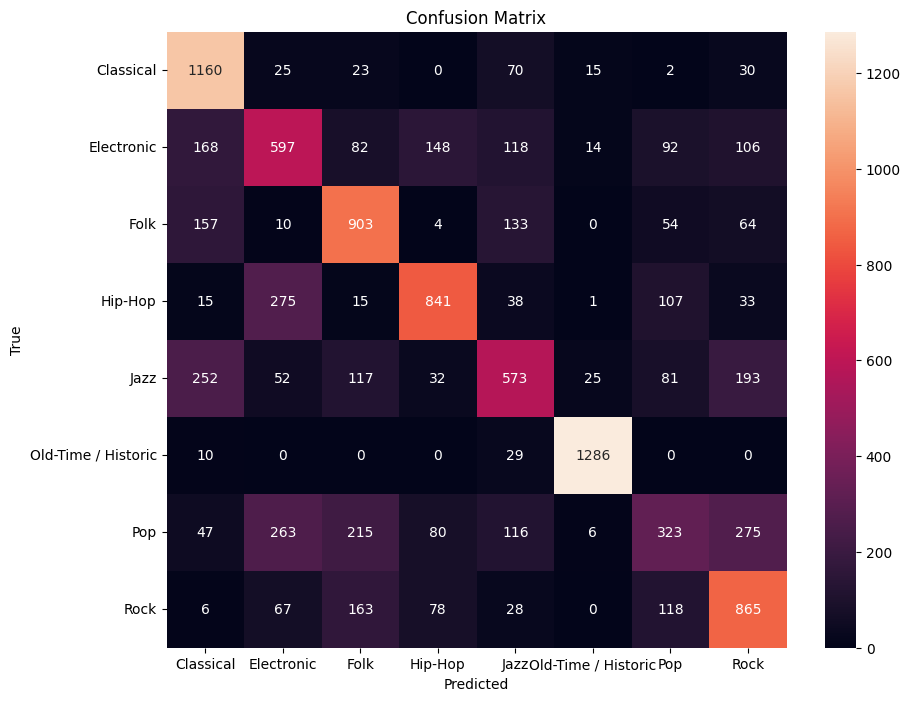

Classification Report Test Set:
                      precision    recall  f1-score   support

          Classical       0.64      0.88      0.74      1325
         Electronic       0.46      0.45      0.46      1325
               Folk       0.59      0.68      0.64      1325
            Hip-Hop       0.71      0.63      0.67      1325
               Jazz       0.52      0.43      0.47      1325
Old-Time / Historic       0.95      0.97      0.96      1325
                Pop       0.42      0.24      0.31      1325
               Rock       0.55      0.65      0.60      1325

           accuracy                           0.62     10600
          macro avg       0.61      0.62      0.61     10600
       weighted avg       0.61      0.62      0.61     10600

Balanced Accuracy: 0.6177358490566038
F1-Macro: 0.6051797627595938


In [11]:
# ---------------------------------------------------
# CONFUSION MATRIX TEST SET
# ---------------------------------------------------
cm = confusion_matrix(y_test, y_pred,labels=clf.classes_)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report Test Set:\n", classification_report(y_test, y_pred, target_names=clf.classes_))

# Balanced Accuracy
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

# F1-Macro
print("F1-Macro:", f1_score(y_test, y_pred, average='macro'))


In [ ]:
# ---------------------------------------------------------
# IDENTIFY MISCLASSIFIED TEST SAMPLES
# ---------------------------------------------------------

# Create analysis DataFrame
# Create a copy of the original test DataFrame
# This ensures the original data remains unchanged
analysis_df = df_features_tracks_test.copy()
analysis_df['true_genre'] = y_test.astype(str)
analysis_df['predicted_genre'] = y_pred.astype(str)

# Identify misclassified samples
# Filter rows where prediction does not match the true label
misclassified = analysis_df[analysis_df['true_genre'] != analysis_df['predicted_genre']]

# Print misclassification DataFrame
print(misclassified[['track_id', 'true_genre', 'predicted_genre']])

      track_id true_genre      predicted_genre
100     032044  Classical  Old-Time / Historic
105     032044  Classical                 Jazz
113     032044  Classical                 Jazz
114     032044  Classical                 Jazz
115     032044  Classical                 Jazz
...        ...        ...                  ...
10595   001287       Rock                  Pop
10596   001287       Rock              Hip-Hop
10597   001287       Rock              Hip-Hop
10598   001287       Rock              Hip-Hop
10599   001287       Rock                  Pop

[4052 rows x 3 columns]


In [ ]:
# ---------------------------------------------------------
# AGGREGATE MISCLASSIFICATIONS AT TRACK LEVEL
# ---------------------------------------------------------

# Group misclassified segments by track_id and true_genre
# For each track, determine the most frequently predicted (wrong) genre
# This is useful if multiple segments belong to the same track
track_level_preds = (
    misclassified
    .groupby(['track_id', 'true_genre'])['predicted_genre']
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
)

# Print aggregated track-level misclassifications
print(track_level_preds)

# Save results to CSV
track_level_preds[['track_id', 'true_genre', 'predicted_genre']].to_csv(MODEL_RESULTS_DIR / f"{MODEL_NAME}_misclassified_tracks_majority_voting.csv", index=False)

    track_id  true_genre predicted_genre
0     000145        Jazz            Rock
1     000336        Rock      Electronic
2     000406  Electronic            Rock
3     000575        Rock         Hip-Hop
4     000663  Electronic       Classical
..       ...         ...             ...
275   154357  Electronic       Classical
276   154406         Pop         Hip-Hop
277   154407         Pop            Folk
278   154430        Jazz       Classical
279   155306        Folk       Classical

[280 rows x 3 columns]



=== SEGMENT-LEVEL TEST EVALUATION ===
Accuracy: 0.6177358490566037
Macro-F1: 0.6051797627595938

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.64      0.88      0.74      1325
         Electronic       0.46      0.45      0.46      1325
               Folk       0.59      0.68      0.64      1325
            Hip-Hop       0.71      0.63      0.67      1325
               Jazz       0.52      0.43      0.47      1325
Old-Time / Historic       0.95      0.97      0.96      1325
                Pop       0.42      0.24      0.31      1325
               Rock       0.55      0.65      0.60      1325

           accuracy                           0.62     10600
          macro avg       0.61      0.62      0.61     10600
       weighted avg       0.61      0.62      0.61     10600


=== TRACK-LEVEL TEST EVALUATION: MAJORITY VOTING ===
Accuracy: 0.6580188679245284
Macro-F1: 0.64371653850828

Classification Report:
          

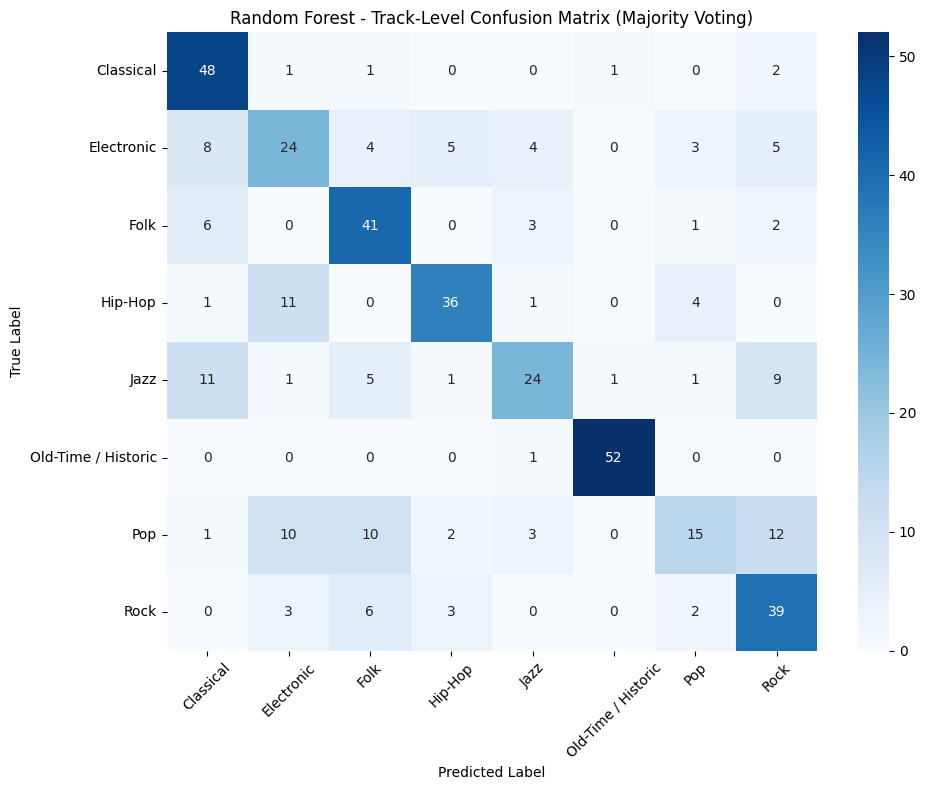


=== TRACK-LEVEL TEST EVALUATION: MEAN PROBABILITY ===
Accuracy: 0.6627358490566038
Macro-F1: 0.6499183860427202

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.67      0.91      0.77        53
         Electronic       0.51      0.51      0.51        53
               Folk       0.63      0.74      0.68        53
            Hip-Hop       0.79      0.72      0.75        53
               Jazz       0.66      0.43      0.52        53
Old-Time / Historic       0.96      0.98      0.97        53
                Pop       0.48      0.28      0.36        53
               Rock       0.57      0.74      0.64        53

           accuracy                           0.66       424
          macro avg       0.66      0.66      0.65       424
       weighted avg       0.66      0.66      0.65       424



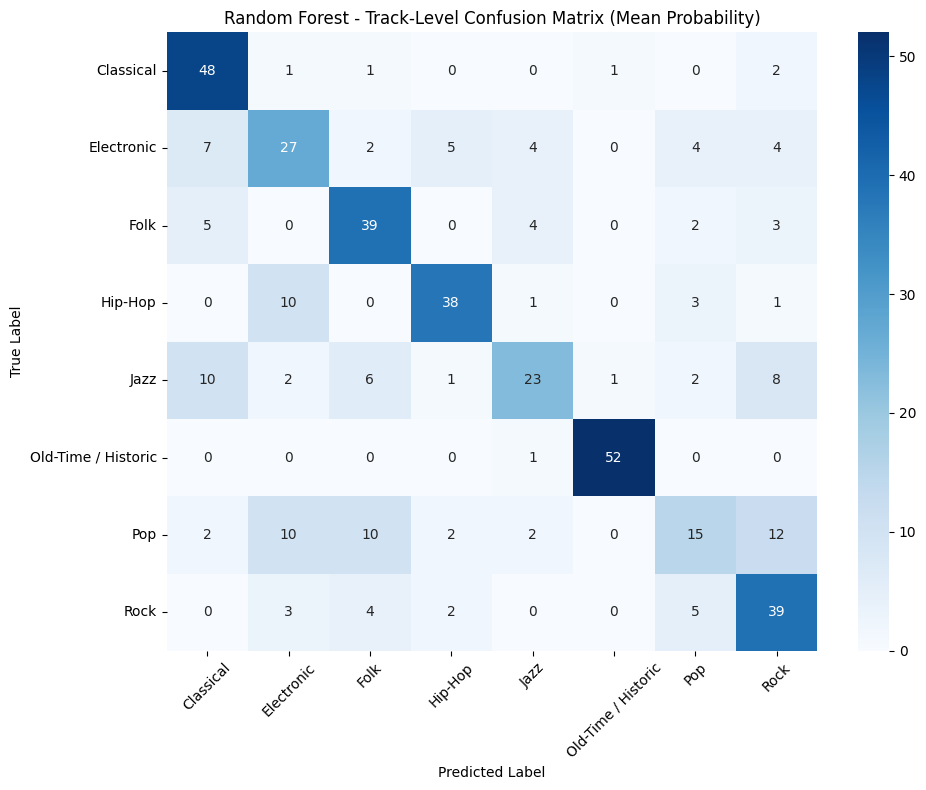


Saved segment- and track-level result CSV files to:
J:/Documents/FH/Git Repo Processing/MA_FMA_Dataprocessing/Models_final/Results


In [ ]:
# ---------------------------------------------------------
# TRACK-LEVEL EVALUATION (TEST SET)
# ---------------------------------------------------------
# The model was trained and evaluated on 3-second segments.
# For a track-level evaluation, all segment predictions belonging to the same
# track_id are aggregated into one final prediction per track.

# Build a metadata DataFrame that has the same row order as X_test / y_test.
# This is required so every segment prediction can be assigned to its original track.
test_meta_df = (
    df_features_tracks_test[df_features_tracks_test["genre"].notna()]
    .reset_index(drop=True)
    .copy()
)

# Safety check: X_test, y_test and metadata must have the same number of rows.
assert len(test_meta_df) == len(y_test) == len(X_test), (
    f"Length mismatch: metadata={len(test_meta_df)}, "
    f"y_test={len(y_test)}, X_test={len(X_test)}"
)

# Segment-level predictions and probabilities.
test_pred_proba = clf.predict_proba(X_test)
segment_pred_labels = clf.predict(X_test)
class_names = list(clf.classes_)

# Store segment-level prediction details in one DataFrame.
segment_analysis_df = test_meta_df[["track_id", "genre"]].copy()
segment_analysis_df["true_genre"] = np.array(y_test).astype(str)
segment_analysis_df["predicted_genre"] = np.array(segment_pred_labels).astype(str)

# Add one probability column per class.
for class_idx, class_name in enumerate(class_names):
    segment_analysis_df[f"prob_{class_name}"] = test_pred_proba[:, class_idx]

# ---------------------------------------------------------
# SEGMENT-LEVEL METRICS
# ---------------------------------------------------------
print("\n=== SEGMENT-LEVEL TEST EVALUATION ===")
print(
    "Accuracy:",
    accuracy_score(
        segment_analysis_df["true_genre"],
        segment_analysis_df["predicted_genre"]
    )
)
print(
    "Macro-F1:",
    f1_score(
        segment_analysis_df["true_genre"],
        segment_analysis_df["predicted_genre"],
        average="macro"
    )
)
print("\nClassification Report:")
print(
    classification_report(
        segment_analysis_df["true_genre"],
        segment_analysis_df["predicted_genre"],
        labels=class_names,
        target_names=class_names
    )
)

# ---------------------------------------------------------
# TRACK-LEVEL AGGREGATION: MAJORITY VOTING
# ---------------------------------------------------------
# Majority voting selects the most frequent segment-level class prediction
# as the final prediction for each track.
track_majority_df = (
    segment_analysis_df
    .groupby(["track_id", "true_genre"])["predicted_genre"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
    .rename(columns={"predicted_genre": "predicted_genre_majority"})
)

print("\n=== TRACK-LEVEL TEST EVALUATION: MAJORITY VOTING ===")
print(
    "Accuracy:",
    accuracy_score(
        track_majority_df["true_genre"],
        track_majority_df["predicted_genre_majority"]
    )
)
print(
    "Macro-F1:",
    f1_score(
        track_majority_df["true_genre"],
        track_majority_df["predicted_genre_majority"],
        average="macro"
    )
)
print("\nClassification Report:")
print(
    classification_report(
        track_majority_df["true_genre"],
        track_majority_df["predicted_genre_majority"],
        labels=class_names,
        target_names=class_names
    )
)

cm_majority = confusion_matrix(
    track_majority_df["true_genre"],
    track_majority_df["predicted_genre_majority"],
    labels=class_names
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_majority,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest - Track-Level Confusion Matrix (Majority Voting)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# TRACK-LEVEL AGGREGATION: MEAN PROBABILITY
# ---------------------------------------------------------
# Mean probability aggregation averages the predicted class probabilities
# across all segments of the same track and selects the class with the
# highest average probability.
prob_cols = [f"prob_{class_name}" for class_name in class_names]

track_probability_df = (
    segment_analysis_df
    .groupby(["track_id", "true_genre"])[prob_cols]
    .mean()
    .reset_index()
)

# Select the class with the highest mean probability as final track prediction.
mean_prob_values = track_probability_df[prob_cols].to_numpy()
track_probability_df["predicted_genre_mean_probability"] = [
    class_names[idx] for idx in np.argmax(mean_prob_values, axis=1)
]

print("\n=== TRACK-LEVEL TEST EVALUATION: MEAN PROBABILITY ===")
print(
    "Accuracy:",
    accuracy_score(
        track_probability_df["true_genre"],
        track_probability_df["predicted_genre_mean_probability"]
    )
)
print(
    "Macro-F1:",
    f1_score(
        track_probability_df["true_genre"],
        track_probability_df["predicted_genre_mean_probability"],
        average="macro"
    )
)
print("\nClassification Report:")
print(
    classification_report(
        track_probability_df["true_genre"],
        track_probability_df["predicted_genre_mean_probability"],
        labels=class_names,
        target_names=class_names
    )
)

cm_mean_probability = confusion_matrix(
    track_probability_df["true_genre"],
    track_probability_df["predicted_genre_mean_probability"],
    labels=class_names
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_mean_probability,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest - Track-Level Confusion Matrix (Mean Probability)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# SAVE TRACK-LEVEL RESULTS
# ---------------------------------------------------------
# Store segment-level and track-level results for later error analysis.
MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Segment-level misclassifications.
segment_misclassified = segment_analysis_df[
    segment_analysis_df["true_genre"] != segment_analysis_df["predicted_genre"]
]

segment_misclassified[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_misclassified_segments.csv",
    index=False
)

# Track-level predictions: Majority Voting.
track_majority_export = track_majority_df.rename(
    columns={"predicted_genre_majority": "predicted_genre"}
)

track_majority_export[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_track_level_predictions_majority.csv",
    index=False
)

# Track-level predictions: Mean Probability.
track_probability_export = track_probability_df.rename(
    columns={"predicted_genre_mean_probability": "predicted_genre"}
)

track_probability_export[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_track_level_predictions_mean_probability.csv",
    index=False
)

# Track-level misclassifications: Majority Voting.
track_majority_misclassified = track_majority_export[
    track_majority_export["true_genre"] != track_majority_export["predicted_genre"]
]

track_majority_misclassified[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_misclassified_tracks_majority.csv",
    index=False
)

# Track-level misclassifications: Mean Probability.
track_probability_misclassified = track_probability_export[
    track_probability_export["true_genre"] != track_probability_export["predicted_genre"]
]

track_probability_misclassified[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_misclassified_tracks_mean_probability.csv",
    index=False
)

print("\nSaved segment- and track-level result CSV files to:")
print(MODEL_RESULTS_DIR)